In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [2]:
from src.transforms import trainval_transforms, revert_normalization, revert_standardization
from src.dataset import ImageDataset
import torch

annot_path = Path("../data/preprocessed/trainval/annotations.csv")
img_dir = Path("../data/preprocessed/trainval/images")

# test dataset without transforms
dataset = ImageDataset(annot_path, img_dir, transform=trainval_transforms)

In [28]:
image, labels = next(iter(dataset))
obj_coords = []

In [29]:
revert_standardization(image)
image = revert_normalization(image)

In [30]:
from src.utilities import convert_xywh_coordinates

for i in range(7):
    for j in range(7):
        coord = labels[i][j][20:24]
        
        if torch.any(coord):
            obj_coords.append(
                convert_xywh_coordinates(coord, i, j, True)
            )

In [31]:
obj_coords

[(124, 111, 140, 131),
 (108, 116, 132, 178),
 (2, 146, 30, 224),
 (74, 158, 114, 222),
 (118, 126, 144, 202)]

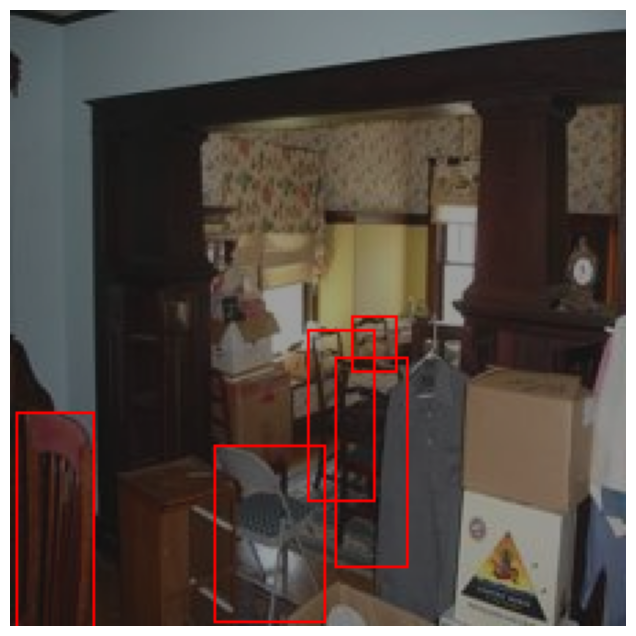

In [32]:
from matplotlib import pyplot as plt
import bbox_visualizer as bbv

fig, ax = plt.subplots(1, figsize=(8, 8))

image = image.permute(1, 2, 0).numpy()

image = bbv.draw_multiple_rectangles(image, obj_coords, bbox_color=(255, 0, 0), thickness=1)

ax.imshow(image)
ax.axis(False)

plt.show()